In [2]:
pip install torch torchvision opencv-python matplotlib numpy pillow

   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.0 MB ? eta -:--:--
    --------------------------------------- 0.5/39.0 MB 882.6 kB/s eta 0:00:44
    --------------------------------------- 0.5/39.0 MB 882.6 kB/s eta 0:00:44
    --------------------------------------- 0.8/39.0 MB 907.1 kB/s eta 0:00:43
   - -------------------------------------- 1.0/39.0 MB 949.8 kB/s eta 0:00:40
   - -------------------------------------- 1.3/39.0 MB 959.4 kB/s eta 0:00:40
   - -------------------------------------- 1.3/39.0 MB 959.4 kB/s eta 0:00:40
   - -------------------------------------- 1.6/39.0 MB 964.5 kB/s eta 0:00:39
   - -------------------------------------- 1.8/39.0 MB 967.9 kB/s eta 0:00:39
   -- ------------------------------------- 2.1/39.0 MB 970.9 kB/s eta 0:00:39
   -- ------------------------------------- 2.4/39.0 MB 972.7 kB/s eta 0:00:38


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns # Pip install seaborn if missing
import os

In [11]:
# ==========================================
# 1. SETUP
# ==========================================
# Use a clean style
plt.style.use('seaborn-v0_8-darkgrid') 
sns.set_context("talk")

MODEL_PATH = "chexpert_model_2gpu.pth"
IMG_SIZE = 320
LABELS = np.array([
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 
    'Support Devices'
])

In [12]:
# ==========================================
# 2. MODEL DEFINITION
# ==========================================
class CheXpertClassifier(nn.Module):
    def __init__(self, num_classes=14):
        super(CheXpertClassifier, self).__init__()
        self.backbone = models.densenet121(weights=None)
        num_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone.features(x)
        out = F.relu(features, inplace=False) 
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        out = self.backbone.classifier(out)
        return out

In [13]:
# ==========================================
# 3. GRAD-CAM ENGINE
# ==========================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self):
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]
        heatmap = torch.mean(activations, dim=0).cpu().detach().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= np.max(heatmap) + 1e-8
        return heatmap

# ==========================================
# 4. MODERN VISUALIZATION
# ==========================================
def analyze_image(image_path):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"🚀 Processing: {image_path}...")

    # A. Load Model
    model = CheXpertClassifier(num_classes=14)
    if not os.path.exists(MODEL_PATH):
        print(f"❌ Error: {MODEL_PATH} not found.")
        return
    
    state_dict = torch.load(MODEL_PATH, map_location=device)
    new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()

    target_layer = model.backbone.features.norm5
    grad_cam = GradCAM(model, target_layer)

    # B. Process Image
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    try:
        original_pil = Image.open(image_path).convert("RGB")
        img_tensor = transform(original_pil).unsqueeze(0).to(device)
        img_tensor.requires_grad = True
    except Exception as e:
        print(f"❌ Image Error: {e}")
        return

    # C. Predict
    model.zero_grad()
    output = model(img_tensor)
    probs = torch.sigmoid(output).cpu().detach().numpy()[0]
    
    # Sort predictions for better UI
    sorted_indices = np.argsort(probs) # Ascending
    sorted_labels = LABELS[sorted_indices]
    sorted_probs = probs[sorted_indices]
    
    top_idx = sorted_indices[-1] # The highest score
    top_label = LABELS[top_idx]
    
    # D. Explain (Heatmap)
    output[:, top_idx].backward()
    heatmap = grad_cam.generate_heatmap()
    
    # Resize & Colorize
    original_cv = np.array(original_pil)
    heatmap = cv2.resize(heatmap, (original_cv.shape[1], original_cv.shape[0]))
    
    # Thresholding: Hide low activation areas so they don't block the X-ray
    heatmap[heatmap < 0.2] = 0 
    
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_INFERNO)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Alpha blend
    overlay = cv2.addWeighted(original_cv, 0.7, heatmap_colored, 0.3, 0)

    # ==========================================
    # E. DASHBOARD LAYOUT
    # ==========================================
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])
    
    # 1. Heatmap Panel
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(overlay)
    ax1.set_title(f"AI Focus Area: {top_label}", fontsize=18, fontweight='bold', pad=20)
    ax1.axis('off')
    
    # Add a border color based on risk
    border_color = 'red' if sorted_probs[-1] > 0.5 else 'green'
    for spine in ax1.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    # 2. Risk Bar Chart
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Create colors based on threshold
    bar_colors = ['#e74c3c' if x > 0.5 else '#2ecc71' for x in sorted_probs]
    
    bars = ax2.barh(sorted_labels, sorted_probs, color=bar_colors, edgecolor='none', height=0.6)
    
    # Styling
    ax2.set_xlim(0, 1.05)
    ax2.set_xlabel("Confidence Score", fontsize=14)
    ax2.set_title("Pathology Risk Assessment", fontsize=18, fontweight='bold', pad=20)
    ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax2.grid(False, axis='y') # Only vertical grid lines
    
    # Add Percentage Labels on the bars
    for bar, prob in zip(bars, sorted_probs):
        width = bar.get_width()
        label_x_pos = width + 0.02
        text_color = 'black'
        font_weight = 'bold' if width > 0.5 else 'normal'
        
        ax2.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
                 f"{prob:.1%}", 
                 va='center', fontsize=12, color=text_color, fontweight=font_weight)

    plt.tight_layout(pad=3.0)
    plt.show()

🚀 Processing: chest.jpg...


C:\Users\khali\AppData\Local\Temp\ipykernel_29392\3617998223.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=device)


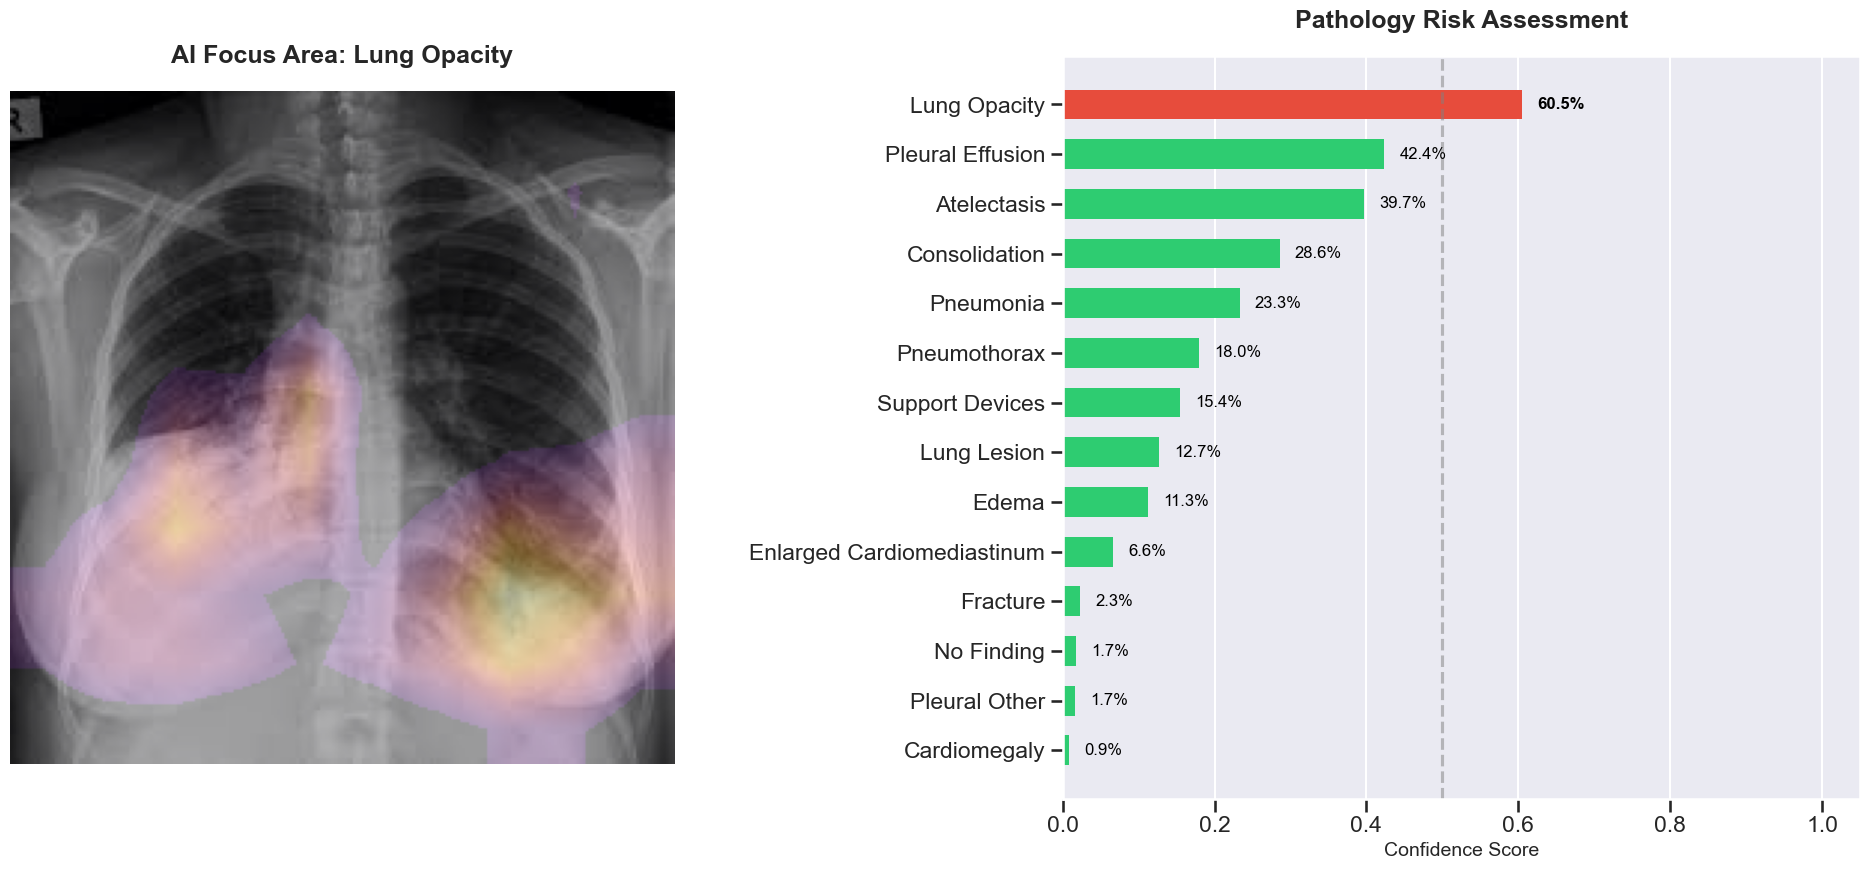

In [14]:
# ==========================================
# 5. RUN
# ==========================================
image_to_test = "chest.jpg" 
if os.path.exists(image_to_test):
    analyze_image(image_to_test)
else:
    print(f"⚠️ Image not found: {image_to_test}")

🚀 Analyzing: chest.jpg


C:\Users\khali\AppData\Local\Temp\ipykernel_29392\1719894361.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=device)


🔍 Top Finding: Lung Opacity (60.5%)


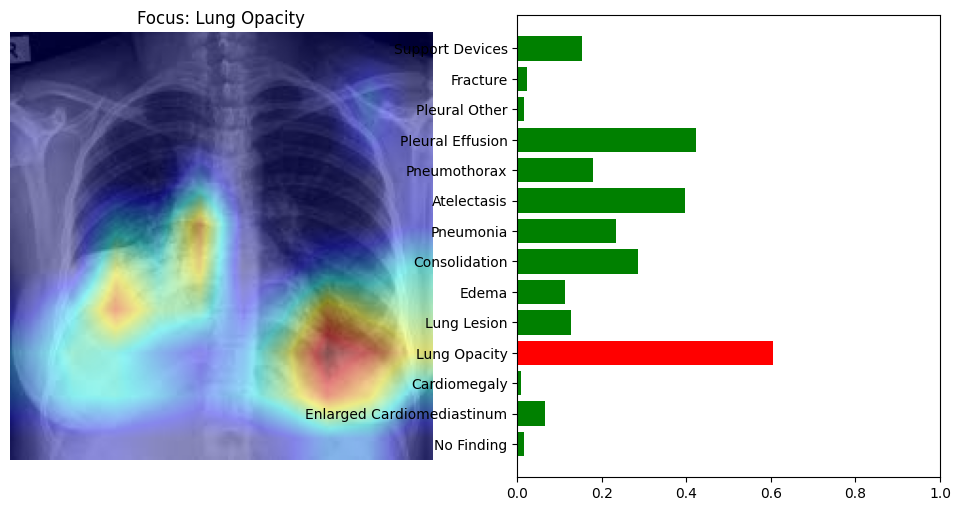